# Experiment: Amazon Fine Food Reviews Cleaning and Exploration

Objective:
- inspect the raw `Reviews.csv` dataset;
- validate the Polars cleaning pipeline;
- visualize the main distributions useful for the V1 semantic search project;
- inspect the product documents generated from review aggregation.


In [8]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(12)


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    while current != current.parent:
        if (current / "pipeline").is_dir() and (current / "backend").is_dir():
            return current
        current = current.parent
    return start.resolve()


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pipeline.reviews_polars import (
    RAW_DATA_PATH,
    PROCESSED_DIR,
    SAMPLES_DIR,
    build_product_documents,
    build_quality_report,
    cleaned_reviews_lazy,
    scan_reviews,
)

PROJECT_ROOT, RAW_DATA_PATH.exists()

(WindowsPath('D:/Licience 3 IA-BD/SEMANTIC-SEARCH'), True)

## Raw dataset inspection

This section checks that the CSV is present, counts the rows, and inspects the declared schema.


In [9]:
raw_reviews = scan_reviews(RAW_DATA_PATH)
raw_schema = raw_reviews.collect_schema()
raw_row_count = raw_reviews.select(pl.len().alias("row_count")).collect().item()

schema_preview = pl.DataFrame(
    {
        "column": list(raw_schema.names()),
        "dtype": [str(dtype) for dtype in raw_schema.dtypes()],
    }
)

display(schema_preview)
print(f"Raw row count: {raw_row_count:,}")
raw_reviews.head(5).collect()

column,dtype
str,str
"""Id""","""Int32"""
"""ProductId""","""String"""
"""UserId""","""String"""
"""ProfileName""","""String"""
"""HelpfulnessNumerator""","""Int32"""
"""HelpfulnessDenominator""","""Int32"""
"""Score""","""Float32"""
"""Time""","""Int32"""
"""Summary""","""String"""


Raw row count: 568,454


Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
i32,str,str,str,i32,i32,f32,i32,str,str
1,"""B001E4KFG0""","""A3SGXH7AUHU8GW""","""delmartian""",1,1,5.0,1303862400,"""Good Quality Dog Food""","""I have bought several of the V…"
2,"""B00813GRG4""","""A1D87F6ZCVE5NK""","""dll pa""",0,0,1.0,1346976000,"""Not as Advertised""","""Product arrived labeled as Jum…"
3,"""B000LQOCH0""","""ABXLMWJIXXAIN""","""Natalia Corres ""Natalia Corres…",1,1,4.0,1219017600,"""""Delight"" says it all""","""This is a confection that has …"
4,"""B000UA0QIQ""","""A395BORC6FGVXV""","""Karl""",3,3,2.0,1307923200,"""Cough Medicine""","""If you are looking for the sec…"
5,"""B006K2ZZ7K""","""A1UQRSCLF8GW1T""","""Michael D. Bigham ""M. Wassir""""",0,0,5.0,1350777600,"""Great taffy""","""Great taffy at a great price. …"


## Cleaning with Polars

The cleaning step removes invalid rows, normalizes text, removes duplicates, and creates derived columns used later by the project.


In [10]:
cleaned_reviews = cleaned_reviews_lazy(RAW_DATA_PATH).collect(engine="streaming")

overview = pl.DataFrame(
    {
        "metric": [
            "raw_rows",
            "cleaned_rows",
            "rows_removed",
            "unique_products",
            "unique_users",
        ],
        "value": [
            raw_row_count,
            cleaned_reviews.height,
            raw_row_count - cleaned_reviews.height,
            cleaned_reviews["ProductId"].n_unique(),
            cleaned_reviews["UserId"].n_unique(),
        ],
    }
)

display(overview)
cleaned_reviews.select(
    [
        "ProductId",
        "Score",
        "HelpfulnessDenominator",
        "helpfulness_ratio",
        "summary_length",
        "text_length",
        "review_text",
    ]
).head(5)

metric,value
str,i64
"""raw_rows""",568454
"""cleaned_rows""",567559
"""rows_removed""",895
"""unique_products""",74258
"""unique_users""",256059


ProductId,Score,HelpfulnessDenominator,helpfulness_ratio,summary_length,text_length,review_text
str,f32,i32,f32,i32,i32,str
"""B000TRFGGM""",3.0,1,1.0,20,438,"""Pretty nice plant!!!. The plan…"
"""B000HB9TLI""",5.0,0,null,32,264,"""Celebration herbals-Hibiscus T…"
"""B005HVDZRM""",5.0,0,null,28,251,"""Twinings---a good cup of tea. …"
"""B001HTR4WA""",5.0,0,null,42,199,"""Horizon aspetic plain organic …"
"""B0001M0Z3O""",5.0,0,null,17,162,"""review correction. Please corr…"


## Quality report

The quality report is the compact summary we can reuse for progress reviews and reporting.


In [11]:
quality_report = build_quality_report(cleaned_reviews, raw_row_count)
print(json.dumps(quality_report, indent=2))

{
  "raw_row_count": 568454,
  "cleaned_row_count": 567559,
  "rows_removed": 895,
  "unique_products": 74258,
  "unique_users": 256059,
  "score_distribution": [
    {
      "Score": 1.0,
      "len": 51989
    },
    {
      "Score": 2.0,
      "len": 29759
    },
    {
      "Score": 3.0,
      "len": 42577
    },
    {
      "Score": 4.0,
      "len": 80592
    },
    {
      "Score": 5.0,
      "len": 362642
    }
  ],
  "quality_checks": {
    "missing_product_id": 0,
    "missing_summary_and_text": 0,
    "score_out_of_range": 0,
    "helpfulness_invalid": 0
  },
  "zero_helpfulness_denominator": 269767,
  "short_reviews_under_80_chars": 3612,
  "long_reviews_over_1500_chars": 14386,
  "reviews_per_product": {
    "median": 2,
    "p90": 13,
    "p95": 26,
    "max": 913
  },
  "text_length_quantiles": {
    "p50": 297,
    "p90": 852,
    "p99": 2070
  },
  "year_distribution": [
    {
      "year": 1999,
      "len": 6
    },
    {
      "year": 2000,
      "len": 32
    },
  

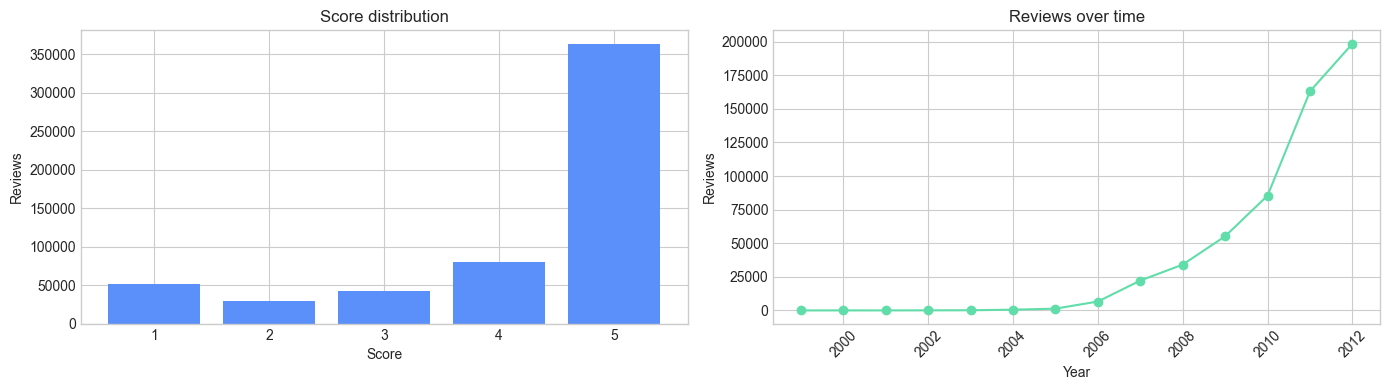

In [12]:
score_distribution = pl.DataFrame(quality_report["score_distribution"])
year_distribution = pl.DataFrame(quality_report["year_distribution"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    score_distribution["Score"].to_list(),
    score_distribution["len"].to_list(),
    color="#5B8FF9",
)
axes[0].set_title("Score distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Reviews")

axes[1].plot(
    year_distribution["year"].to_list(),
    year_distribution["len"].to_list(),
    marker="o",
    color="#61DDAA",
)
axes[1].set_title("Reviews over time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Reviews")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

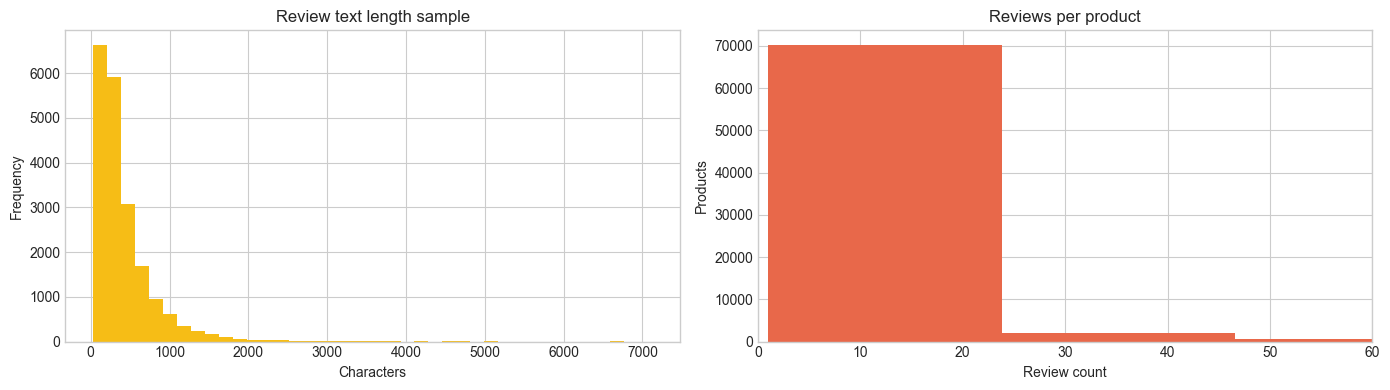

In [13]:
text_length_sample = cleaned_reviews.select("text_length").sample(
    n=min(20000, cleaned_reviews.height),
    seed=7,
)
reviews_per_product = (
    cleaned_reviews.group_by("ProductId").len().rename({"len": "review_count"})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(text_length_sample["text_length"].to_list(), bins=40, color="#F6BD16")
axes[0].set_title("Review text length sample")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")

axes[1].hist(reviews_per_product["review_count"].to_list(), bins=40, color="#E8684A")
axes[1].set_title("Reviews per product")
axes[1].set_xlabel("Review count")
axes[1].set_ylabel("Products")
axes[1].set_xlim(0, 60)

plt.tight_layout()
plt.show()

## Product documents for semantic search

This is the representation that will later feed embeddings, indexing, and retrieval.


In [14]:
product_documents = build_product_documents(cleaned_reviews)

display(
    product_documents.select(
        [
            "ProductId",
            "label_hint",
            "review_count",
            "average_score",
            "average_helpfulness_ratio",
        ]
    ).head(10)
)

product_documents.select(["ProductId", "search_text"]).head(3)

ProductId,label_hint,review_count,average_score,average_helpfulness_ratio
str,str,i32,f32,f32
"""B007JFMH8M""","""Delicious""",913,4.58,0.901
"""B0026RQTGE""","""Our Dogs LOVE These and We Do …",630,4.59,0.782
"""B002QWHJOU""","""Our Dogs LOVE These and We Do …",630,4.59,0.782
"""B002QWP89S""","""Our Dogs LOVE These and We Do …",630,4.59,0.782
"""B002QWP8H0""","""Our Dogs LOVE These and We Do …",630,4.59,0.782
"""B003B3OOPA""","""YUM! AMBROSIA!""",623,4.74,0.878
"""B001EO5Q64""","""Best Tasting Coconut Oil I've …",567,4.75,0.86
"""B000VK8AVK""","""Not exactly like traditional p…",564,4.31,0.735
"""B0013NUGDE""","""Not exactly like traditional p…",564,4.31,0.735


ProductId,search_text
str,str
"""B007JFMH8M""","""ProductId: B007JFMH8M. Label h…"
"""B0026RQTGE""","""ProductId: B0026RQTGE. Label h…"
"""B002QWHJOU""","""ProductId: B002QWHJOU. Label h…"


In [15]:
expected_outputs = [
    PROCESSED_DIR / "reviews_cleaned.parquet",
    PROCESSED_DIR / "product_documents.parquet",
    PROCESSED_DIR / "quality_report.json",
    SAMPLES_DIR / "reviews_cleaned_sample.parquet",
    SAMPLES_DIR / "product_documents_sample.parquet",
]

status_rows = []
for path in expected_outputs:
    status_rows.append(
        {"file": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists()}
    )

display(pl.DataFrame(status_rows))

file,exists
str,bool
"""data\processed\reviews_cleaned…",true
"""data\processed\product_documen…",true
"""data\processed\quality_report.…",false
"""data\samples\reviews_cleaned_s…",true
"""data\samples\product_documents…",true


## Next steps

- run the notebook top to bottom once the local environment is fully stable;
- compare cleaned review statistics with the product document statistics;
- connect the next steps of the pipeline to real embeddings and Qdrant indexing;
- reuse the charts and quality report in the daily log and final synthesis.
